# Create LDA for Brandon Sanderson Corpus

## Install Packages

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF

In [2]:
sns.set_theme(style="white")
pio.renderers.default = "notebook"

#### Set Model Parameters

In [3]:
model_type = 'lda'
colors = 'YlGnBu'

In [4]:
OHCO = ['title', 'chapter_id', 'paragraph_id', 'sent_id', 'token_id']
PARA = OHCO[:3]
CHAP = OHCO[:2]
BOOK = OHCO[:1]
BAG = CHAP

## Get Data

In [5]:
directory_path  = 'C:/Users/mason/Box/Text As Data Final/Output'
TOKENS = pd.read_csv(f"{directory_path}/BrandonSanderson_CORPUS.csv", index_col=0).set_index(OHCO)
TOKENS.head()

token_str term_str  \
title             chapter_id paragraph_id sent_id token_id                      
A Memory of Light 0          0            0       0              The      the   
                                                  1            Wheel    wheel   
                                                  2               of       of   
                                                  3             Time     time   
                                                  4            turns    turns   

                                                            pos pos_group  
title             chapter_id paragraph_id sent_id token_id                 
A Memory of Light 0          0            0       0          DT        DT  
                                                  1         NNP        NN  
                                                  2          IN        IN  
                                                  3         NNP        NN  
                                                  4         NNS        NN

## Convert to a `DOCS` table filtering for Nouns, Verbs, Adjectives, and Adverbs

In [6]:
DOCS = TOKENS[TOKENS.pos.str.match(r'^(NN(?!P)|VB|JJ|RB)')]\
    .groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str, x)))\
    .to_frame()\
    .rename(columns={'term_str': 'doc_str'})
DOCS.head()


doc_str
title             chapter_id                                                   
A Memory of Light 0           turns come pass leaving memories become legend...
                  1           pevara did very best pretend was not terrified...
                  2           have indeed patched differences said sitting c...
                  3           was end said sitting wall feel emotions sat st...
                  4           al awoke drew deep breath slipped blankets ten...

## Create Vector Space

In [7]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS)
custom_stops = [
    'know', 'asked', 'think', 'people', 'man', 'eyes', 'make', 
    'going', 'want', 'need', 'right', 'got', 'good', 'look', 
    'long', 'away', 'men', 'woman', 'felt', 'did', 'didn', 'don',
    'll', 've', 're', 'nt'
]
my_stop_words.extend(custom_stops)

In [8]:
count_engine = CountVectorizer(max_df = 0.25, min_df=10, stop_words=my_stop_words, ngram_range=(1, 2))
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

aback  abandon  abandoned  \
title                          chapter_id                              
A Memory of Light              0               0        0          1   
                               1               0        1          0   
                               2               0        0          0   
                               3               0        0          0   
                               4               0        0          0   
...                                          ...      ...        ...   
Words of Radiance              4               0        0          2   
                               5               0        0          0   
                               6               0        0          0   
                               7               0        0          0   
Yumi and the Nightmare Painter 0               0        0          0   

                                           abandoning  abashed  abilities  \
title                          chapter_id                                   
A Memory of Light              0                    0        0          1   
                               1                    0        0          0   
                               2                    0        0          0   
                               3                    0        0          0   
                               4                    0        0          0   
...                                               ...      ...        ...   
Words of Radiance              4                    0        0          1   
                               5                    0        0          0   
                               6                    0        0          0   
                               7                    0        0          2   
Yumi and the Nightmare Painter 0                    1        0          0   

                                           ability  able escape  able hear  \
title                          chapter_id                                    
A Memory of Light              0                 1            0          0   
                               1                 0            0          0   
                               2                 1            0          0   
                               3                 0            0          0   
                               4                 0            0          0   
...                                            ...          ...        ...   
Words of Radiance              4                 0            0          0   
                               5                 0            0          0   
                               6                 0            0          0   
                               7                 1            0          0   
Yumi and the Nightmare Painter 0                 0            0          0   

                                           able help  ...  youth  youthful  \
title                          chapter_id             ...                    
A Memory of Light              0                   0  ...      2         0   
                               1                   0  ...      0         0   
                               2                   0  ...      0         0   
                               3                   0  ...      0         0   
                               4                   0  ...      1         0   
...                                              ...  ...    ...       ...   
Words of Radiance              4                   0  ...      0         0   
                               5                   0  ...      0         0   
                               6                   0  ...      0         0   
                               7                   0  ...      0         0   
Yumi and the Nightmare Painter 0                   0  ...      0         0   

                                           youths  youyou  zephyr  \
title

In [21]:
DTM.to_csv(f"{directory_path}/BrandonSanderson_DTM.csv")

## Generate Model

In [9]:
n_topics = 15
max_iter = 100
n_top_terms = 10
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [10]:
if model_type == 'lda':
    topic_engine = LDA(n_components=n_topics, max_iter=max_iter)
elif model_type == 'nmf':
    topic_engine = NMF(n_components=n_topics, max_iter=max_iter)
topic_model = topic_engine.fit_transform(count_model)

## `THETA` table

In [11]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

#### Save Theta Table

In [12]:
THETA.to_csv(f"{directory_path}/BrandonSanderson_THETA.csv")

## PHI

In [13]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap=colors, axis=None)

term_str,increased weight,bear,cards,robes,dismissed,inthe,bitter,softened,reports,stoic
topic_id,,,,,,,,,,
T00,0.066667,0.066667,0.066667,12.692670,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T01,0.066667,0.066667,0.066667,7.695441,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T02,35.066666,0.066667,4.079014,0.066667,4.043618,2.697843,0.066667,0.066667,0.066667,1.086755
T03,0.066667,3.219406,0.066668,12.583230,0.066667,0.066667,0.066667,0.066667,2.889855,0.066667
T04,0.066667,2.034930,5.112777,0.066667,0.066667,0.066667,1.232803,0.066667,0.066667,3.108717
T05,0.066667,0.066667,0.066667,12.366224,18.283798,0.066667,0.066667,0.066667,0.066667,0.066667
T06,0.066667,3.969618,0.066667,1.032537,0.066667,0.066667,0.066667,0.066667,43.084170,0.066667
T07,0.066667,0.066667,23.713186,0.066667,0.066667,0.066667,2.393038,0.066667,0.066667,0.066667
T08,0.066667,6.886918,0.066667,0.066667,1.445153,0.066667,0.066667,7.386990,0.066667,0.066667


#### Save PHI table

In [14]:
PHI.to_csv(f"{directory_path}/BrandonSanderson_PHI.csv")

## Topics

In [15]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,mists skaa kandra metals book hat coin fellow ...
T01,priests priest sule elantrian gods chapel god ...
T02,gun ship train bubble speed bullets waxillium ...
T03,emperor soul stamp seal bed weave book test st...
T04,ship spores captain tress deck crew island vin...
T05,spren tower shallan storms fused spheres spher...
T06,camp gateway bloody tent forces battlefield wo...
T07,boy tree children trees island corpse bird lan...
T08,tunnel steel gun hole hallway mobile dust cham...


In [16]:
TOPICS.to_csv(f"{directory_path}/BrandonSanderson_LDA_TOPICS.csv")

## Topics by Doc Weight

#### Mean

In [17]:
TOPICS['doc_weight_mean'] = THETA.mean()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_mean', ascending=False).head(5).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\mason\AppData\Local\Temp\ipykernel_13296\1845078788.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\mason\AppData\Local\Temp\ipykernel_13296\1845078788.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_mean,term_freq
topic_id,,,
T13,lord lady palace throne brother children servants lord said crowd eyebrow,0.187430,0.203428
T10,planet spike notes mask rusts information bomb story sister god,0.095576,0.066371
T02,gun ship train bubble speed bullets waxillium car bullet weight,0.089772,0.084510
T12,cloak horses horse village inn trees al gleeman wolves road,0.084925,0.115754
T04,ship spores captain tress deck crew island vines sailors sea,0.079352,0.044604


#### Sum

In [18]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\mason\AppData\Local\Temp\ipykernel_13296\2717084757.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\mason\AppData\Local\Temp\ipykernel_13296\2717084757.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_mean,term_freq,doc_weight_sum
topic_id,,,,
T13,lord lady palace throne brother children servants lord said crowd eyebrow,0.187430,0.203428,121.829731
T10,planet spike notes mask rusts information bomb story sister god,0.095576,0.066371,62.124465
T02,gun ship train bubble speed bullets waxillium car bullet weight,0.089772,0.084510,58.351845
T12,cloak horses horse village inn trees al gleeman wolves road,0.084925,0.115754,55.201362
T04,ship spores captain tress deck crew island vines sailors sea,0.079352,0.044604,51.578907
T11,spear bridge soldier rock storm knife armor bridgemen battlefield rain,0.076847,0.090645,49.950234
T06,camp gateway bloody tent forces battlefield wolf troops river armies,0.062512,0.091020,40.632826
T01,priests priest sule elantrian gods chapel god palace princess colors,0.056137,0.044887,36.489162
T00,mists skaa kandra metals book hat coin fellow house nice,0.051579,0.041528,33.526546


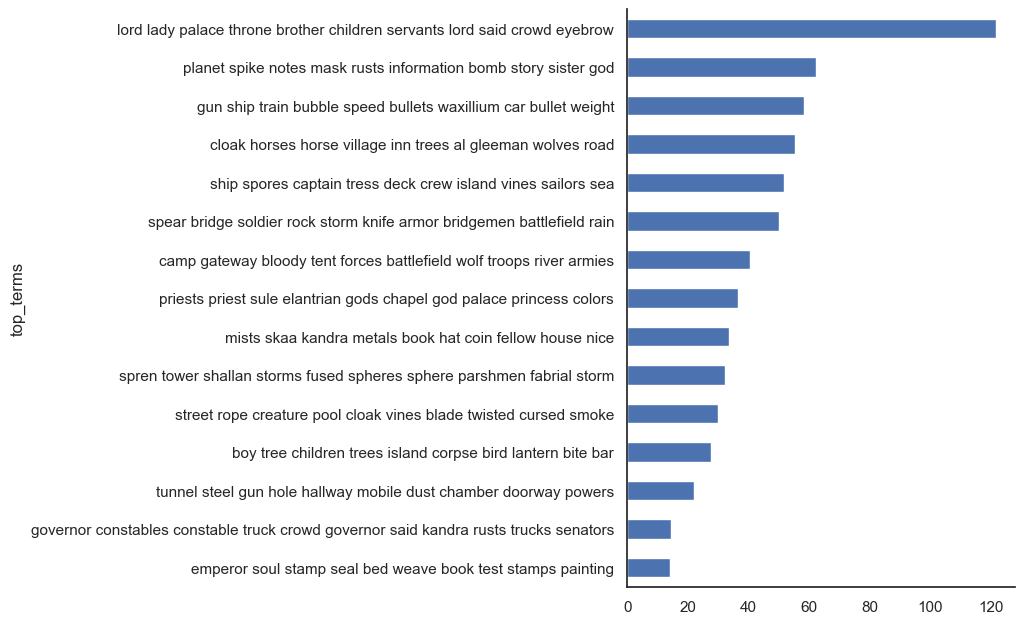

In [19]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

## Topics by Book

In [20]:
TOPIC_BOOK = THETA.groupby('title').mean()
TOPIC_BOOK.T.style.background_gradient(axis=0, cmap="YlGnBu")

title,A Memory of Light,Arcanum Unbounded,Elantris,Isles of the Emberdark,Oathbringer,Rhythm of War,Shadows of Self,Steelheart,The Aether of Night,The Alloy of Law,The Bands of Mourning,The Final Empire,The Hero of Ages,The Lost Metal,The Sunlit Man,The Way of Kings,The Well of Ascension,The Wheel of Time,Towers of Midnight,Tress of the Emerald Sea,Warbreaker,Wind and Truth,Words of Radiance,Yumi and the Nightmare Painter
topic_id,,,,,,,,,,,,,,,,,,,,,,,,
T00,0.002980,0.003663,0.002702,0.008900,0.035416,0.003341,0.166947,0.006015,0.001215,0.150528,0.218723,0.243578,0.181080,0.089450,0.007046,0.072289,0.136160,0.000254,0.007287,0.048863,0.043868,0.027363,0.003575,0.119819
T01,0.000130,0.064380,0.262836,0.089912,0.010335,0.001198,0.043607,0.002968,0.012022,0.016908,0.013818,0.015454,0.090199,0.022737,0.007771,0.025631,0.016573,0.002075,0.002287,0.013881,0.246154,0.006182,0.000223,0.000392
T02,0.010510,0.000411,0.005760,0.034377,0.010328,0.006618,0.158321,0.150623,0.013742,0.413821,0.290673,0.030338,0.017648,0.223525,0.492283,0.017728,0.031765,0.000086,0.000087,0.042143,0.007370,0.017823,0.012423,0.000392
T03,0.004154,0.352366,0.013689,0.015845,0.001068,0.000072,0.007491,0.000032,0.002718,0.018233,0.007987,0.025329,0.000315,0.007704,0.029013,0.047035,0.000632,0.001759,0.094552,0.020078,0.013987,0.000148,0.000223,0.000392
T04,0.001531,0.018665,0.010010,0.075812,0.010357,0.010022,0.004328,0.000032,0.001877,0.005564,0.014988,0.006157,0.004128,0.014740,0.030181,0.044017,0.000632,0.006530,0.001424,0.646482,0.007702,0.040900,0.075210,0.090192
T05,0.001511,0.039099,0.002520,0.012591,0.281315,0.476648,0.007509,0.109344,0.004312,0.008326,0.007873,0.018913,0.003946,0.018633,0.058704,0.117551,0.005537,0.000086,0.006182,0.016424,0.024760,0.297427,0.137262,0.138303
T06,0.510481,0.000411,0.009511,0.026250,0.024812,0.015945,0.007776,0.015242,0.077212,0.009177,0.004314,0.009945,0.103123,0.009050,0.024332,0.040636,0.027059,0.015511,0.358808,0.005580,0.030652,0.007185,0.028726,0.000392
T07,0.013629,0.014739,0.007144,0.413835,0.065046,0.011149,0.023564,0.004771,0.007998,0.014747,0.034892,0.032952,0.062665,0.029594,0.011266,0.028671,0.024288,0.068876,0.043670,0.042527,0.023891,0.000148,0.008907,0.182567
T08,0.024572,0.069139,0.012449,0.015874,0.055532,0.025679,0.049474,0.499798,0.008464,0.036090,0.061558,0.089349,0.002526,0.033426,0.004224,0.032772,0.028859,0.008906,0.034190,0.011308,0.072334,0.002375,0.000223,0.000392
